<a href="https://colab.research.google.com/github/rizkiaalfath3-oss/PDAM_POSTMAN/blob/main/praktikum_analisis_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# membaca dataset
df = pd.read_csv('data_praktikum_analisis_data.csv')

# menampilkan data awal
df.head()

,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
0,1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0
1,1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0
2,1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0
3,1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0


In [7]:
# melihat informasi dataset
print(df.info())

# mengecek data kosong
print(df.isnull().sum())

# membersihkan nama kolom
df.columns = df.columns.str.strip()

# mengubah tipe data tanggal
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# melihat 5 data awal
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    int64  
 1   CustomerID        150 non-null    int64  
 2   Order_Date        150 non-null    object 
 3   Product_Category  150 non-null    object 
 4   Quantity          150 non-null    int64  
 5   Price_Per_Unit    150 non-null    float64
 6   Ad_Budget         150 non-null    float64
 7   Total_Sales       143 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 9.5+ KB
None
Order_ID            0
CustomerID          0
Order_Date          0
Product_Category    0
Quantity            0
Price_Per_Unit      0
Ad_Budget           0
Total_Sales         7
dtype: int64


,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
0,1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0
1,1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0
2,1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0
3,1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0


In [8]:
# menentukan tanggal snapshot
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

# membuat RFM
rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
})

# rename kolom
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# menampilkan hasil
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
5001,213,4,8562000.0
5002,77,4,6931000.0
5003,118,3,9433000.0
5004,196,3,15368000.0
5005,23,2,9105000.0


In [9]:
# membuat score RFM
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

# menggabungkan score
rfm['RFM_Group'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

# tampilkan data
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Group
CustomerID,,,,,,,
5001,213,4,8562000.0,1,4,3,143
5002,77,4,6931000.0,3,4,3,343
5003,118,3,9433000.0,3,2,3,323
5004,196,3,15368000.0,2,3,4,234
5005,23,2,9105000.0,5,2,3,523


In [10]:
# analisis kategori produk
kategori = df.groupby('Product_Category').agg({
    'Total_Sales':'sum',
    'Ad_Budget':'sum'
})

# menghitung efisiensi
kategori['Efisiensi'] = (
    kategori['Total_Sales'] /
    kategori['Ad_Budget']
)

# urutkan
kategori = kategori.sort_values(
    by='Efisiensi'
)

# tampilkan data
kategori

,Total_Sales,Ad_Budget,Efisiensi
Product_Category,,,
Gadget,70523000.0,76539000.0,0.921400
Home Decor,69340000.0,64808000.0,1.069930
Fashion,96550000.0,82317000.0,1.172905
Books,107569000.0,89914000.0,1.196354
Electronics,114095000.0,79264000.0,1.439430


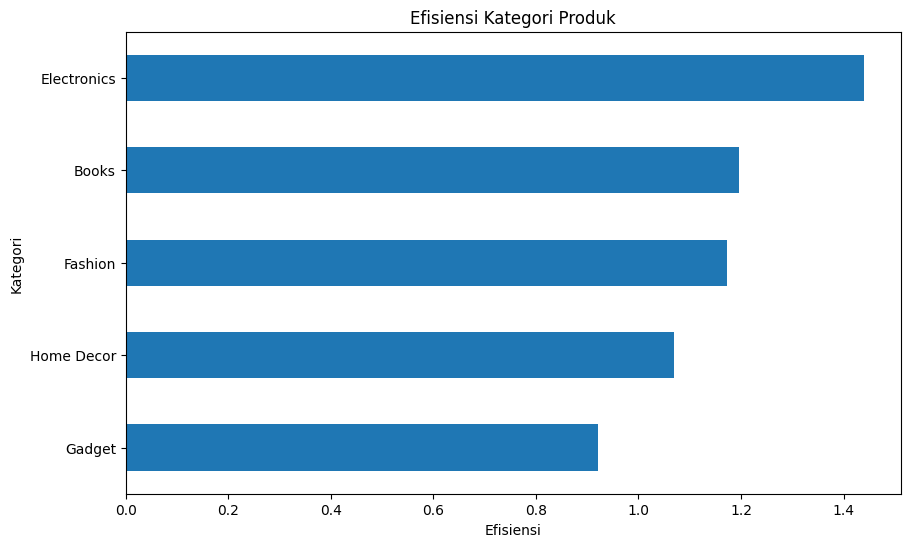

In [11]:
# visualisasi efisiensi kategori
kategori['Efisiensi'].plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Efisiensi Kategori Produk')
plt.xlabel('Efisiensi')
plt.ylabel('Kategori')

plt.show()

In [12]:
# mencari median iklan
median_ads = df['Ad_Budget'].median()

# membagi kelompok
iklan_tinggi = df[
    df['Ad_Budget'] > median_ads
]

iklan_rendah = df[
    df['Ad_Budget'] <= median_ads
]

# rata-rata penjualan
print("Rata-rata penjualan iklan tinggi:")
print(iklan_tinggi['Total_Sales'].mean())

print()

print("Rata-rata penjualan iklan rendah:")
print(iklan_rendah['Total_Sales'].mean())

Rata-rata penjualan iklan tinggi:
3156275.362318841

Rata-rata penjualan iklan rendah:
3247216.2162162163


In [13]:
# mencari median iklan
median_ads = df['Ad_Budget'].median()

# membagi kelompok
iklan_tinggi = df[
    df['Ad_Budget'] > median_ads
]

iklan_rendah = df[
    df['Ad_Budget'] <= median_ads
]

# rata-rata penjualan
print("Rata-rata penjualan iklan tinggi:")
print(iklan_tinggi['Total_Sales'].mean())

print()

print("Rata-rata penjualan iklan rendah:")
print(iklan_rendah['Total_Sales'].mean())

Rata-rata penjualan iklan tinggi:
3156275.362318841

Rata-rata penjualan iklan rendah:
3247216.2162162163


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Drop rows with NaN values in 'Total_Sales'
df_cleaned = df.dropna(subset=['Total_Sales'])

# fitur dan target
X = df_cleaned[['Ad_Budget']]
y = df_cleaned['Total_Sales']

# membagi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# membuat model
model = LinearRegression()

# training model
model.fit(X_train, y_train)

# hasil model
print("Koefisien Iklan:")
print(model.coef_[0])

print()

print("R2 Score:")
print(model.score(X_test, y_test))

Koefisien Iklan:
0.1841982749623798

R2 Score:
-0.1956467472142791
